# Batch ODE Kinetic Fitting

Run the full DK → ODE fitting pipeline on all samples in a `.cxw` file.
This notebook demonstrates:
- Loading a `.cxw` experiment file
- Running `batch_fit(mode='ode')` for all samples
- Flagging poor fits and non-specific binders
- Saving individual data-vs-model plots as PNGs
- Exporting a summary CSV

In [7]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sensefit import load_cxw, batch_fit, flag_poor_fits
from sensefit.plotting import plot_fit, save_fit_plots

## Configure Paths

Set the input `.cxw` file and output directory for plots and CSV.

In [8]:
# --- Edit these paths ---
CXW_FILE = '../20250826_DENV-2 NS2B3 Binding Assay.cxw'
OUTPUT_DIR = Path('../results/ode_batch')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Input:  {CXW_FILE}')
print(f'Output: {OUTPUT_DIR.resolve()}')

Input:  ../20250826_DENV-2 NS2B3 Binding Assay.cxw
Output: /Users/bvh64415/Downloads/creoptix/results/ode_batch


## Run Batch ODE Fitting

Fits every sample cycle using Direct Kinetics → ODE refinement.
Non-specific binders are detected and skipped automatically.

In [9]:
df, data = batch_fit(CXW_FILE, mode='ode', include_nsb=True, progress=True)
df = flag_poor_fits(df)
print(f'\n{len(df)} samples fitted, {df["flag"].sum()} flagged')

  Done: 75 samples in 644.8s (8.6s/sample)                              

75 samples fitted, 40 flagged


## Results Summary

Display the kinetic parameters table. Flagged rows indicate fits that may need manual review.

In [10]:
# Key columns for review
cols = ['compound', 'concentration_uM', 'ka', 'kd', 'KD_uM', 'Rmax',
        'sigma_res', 'nonspecific', 'flag', 'flag_reason']
display_cols = [c for c in cols if c in df.columns]
df[display_cols].head(20)

,compound,concentration_uM,ka,kd,KD_uM,Rmax,sigma_res,nonspecific,flag,flag_reason
0,ASAP-0017237,25.0,0.100000,0.166931,1.669308e+06,1.000000,2.791668,False,True,ka_at_bound
1,ASAP-0017634,25.0,0.100010,0.031456,3.145301e+05,1.000000,0.371588,False,True,ka_at_bound
2,ASAP-0017637,25.0,0.100000,0.045707,4.570690e+05,1.000000,2.197437,False,True,ka_at_bound
3,ASAP-0017666,25.0,0.100005,0.240432,2.404205e+06,1.000000,2.340946,False,True,ka_at_bound
4,ASAP-0029270,25.0,9592.180981,0.008812,9.186712e-01,1.000000,0.723142,False,False,
5,ASAP-0029295,25.0,0.100042,0.019275,1.926678e+05,1.000002,0.434130,False,True,ka_at_bound
6,ASAP-0029307,25.0,0.100001,0.028232,2.823127e+05,1.000000,0.484993,False,True,ka_at_bound
7,ASAP-0029352,10.0,0.100003,0.013115,1.311490e+05,1.000000,2.157557,False,True,ka_at_bound
8,ASAP-0029691,25.0,0.100000,0.080521,8.052125e+05,1.000000,0.542874,False,True,ka_at_bound
9,ASAP-0029804,25.0,0.100000,0.010791,1.079139e+05,1.000000,0.057026,False,True,ka_at_bound


## Save Fit Plots as PNGs

Re-fit each sample individually to get the full result arrays needed for plotting,
then save annotated data-vs-model overlays.

In [11]:
from sensefit.ode_fitting import fit_sample as ode_fit_sample

samples = data['samples']
results = []

for i, sample in enumerate(samples):
    row = df[df['cycle_index'] == sample['index']]
    if row.empty or row.iloc[0].get('nonspecific', False) or not row.iloc[0].get('success', False):
        results.append(None)
        continue
    try:
        result = ode_fit_sample(sample, data['dmso_cals'], blanks=data['blanks'])
        results.append(result)
    except Exception:
        results.append(None)

plot_dir = str(OUTPUT_DIR / 'plots')
paths = save_fit_plots(results, samples, plot_dir, mode='ode')
n_plots = sum(1 for p in paths if p is not None)
print(f'Saved {n_plots} plot(s) → {plot_dir}/')

Saved 75 plot(s) → ../results/ode_batch/plots/


## Example Fit Plot

Display one of the generated plots inline.

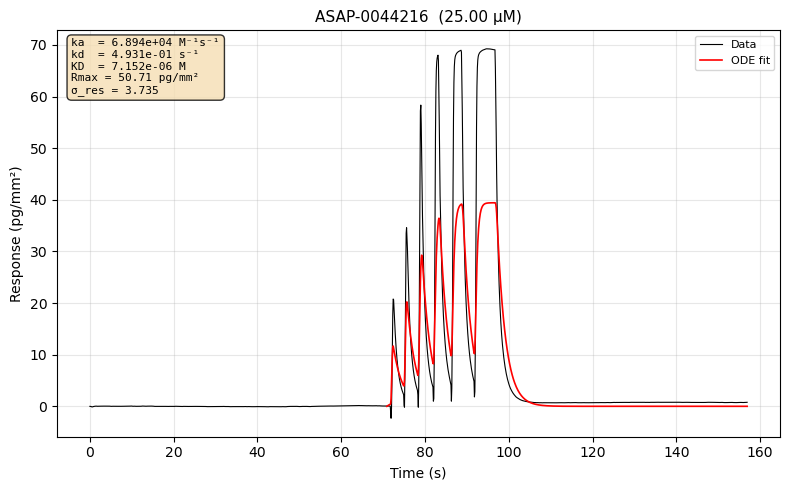

In [12]:
# Show first successful fit
%matplotlib inline
for result, sample in zip(results, samples):
    if result is not None:
        fig = plot_fit(result, sample)
        plt.show()
        break

## Export CSV

Save the full results table with source file, cycle number, sample ID and quality flags.

In [13]:
csv_path = OUTPUT_DIR / 'batch_ode_results.csv'
df.to_csv(csv_path, index=False)
print(f'Results saved → {csv_path}')
print(f'  {len(df)} total samples')
print(f'  {df["nonspecific"].sum()} non-specific binders')
print(f'  {df["flag"].sum()} flagged fits')

Results saved → ../results/ode_batch/batch_ode_results.csv
  75 total samples
  0 non-specific binders
  40 flagged fits
